In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataset
data = {
    "Date": [
        "2026-01-01", "2026-01-02", "2026-01-03",
        "2026-01-04", "2026-01-05", "2026-01-06",
        "2026-01-07", "2026-01-08", "2026-01-09"
    ],
    "Value": [25, 24, 27, 24, 27, 35, 24, 28, 27]
}

df = pd.DataFrame(data)

print(df)
# print(type(df["Date"][0]))

         Date  Value
0  2026-01-01     25
1  2026-01-02     24
2  2026-01-03     27
3  2026-01-04     24
4  2026-01-05     27
5  2026-01-06     35
6  2026-01-07     24
7  2026-01-08     28
8  2026-01-09     27


In [38]:

df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
print(df)
# print(type(df["Date"][0]))

            Value
Date             
2026-01-01     25
2026-01-02     24
2026-01-03     27
2026-01-04     24
2026-01-05     27
2026-01-06     35
2026-01-07     24
2026-01-08     28
2026-01-09     27


In [39]:

# Moving Average
df["MA_3"] = df["Value"].rolling(window=3).mean()

print(df)

            Value       MA_3
Date                        
2026-01-01     25        NaN
2026-01-02     24        NaN
2026-01-03     27  25.333333
2026-01-04     24  25.000000
2026-01-05     27  26.000000
2026-01-06     35  28.666667
2026-01-07     24  28.666667
2026-01-08     28  29.000000
2026-01-09     27  26.333333


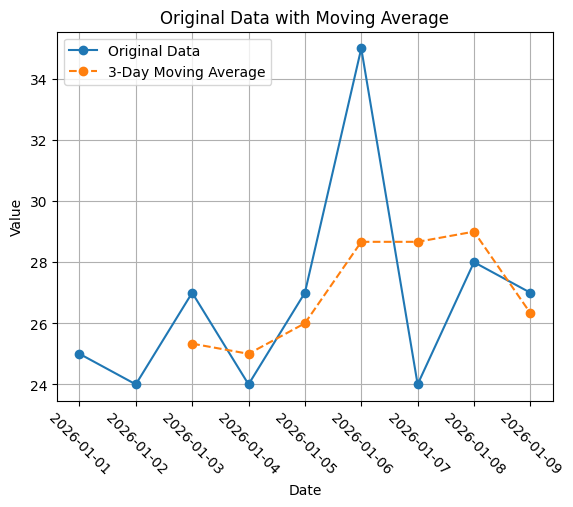

In [40]:
# Plot
plt.figure()
plt.plot(df.index, df["Value"], marker="o", label="Original Data")
plt.plot(df.index, df["MA_3"], marker="o", linestyle="--", label="3-Day Moving Average")
plt.title("Original Data with Moving Average")
plt.xlabel("Date")
plt.ylabel("Value")
plt.xticks(rotation=-45)
plt.legend()
plt.grid(True)
plt.show()


In [41]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(df["Value"], order=(1, 0, 1))
model_fit = model.fit()

# Forecast next value
forecast = model_fit.forecast(steps=1)

print("Predicted value for 10-01-2026:", round(forecast.iloc[0], 2))


Predicted value for 10-01-2026: 26.23


/home/ravi-sparkbrains/Desktop/Learn/ML_Learning/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/ravi-sparkbrains/Desktop/Learn/ML_Learning/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/ravi-sparkbrains/Desktop/Learn/ML_Learning/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [43]:
from pmdarima import auto_arima

# Build Auto-ARIMA model
model = auto_arima(
    df["Value"],
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    d=None,              # let auto-arima decide
    seasonal=False,      # no seasonality
    trace=True,          # shows tried models
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print(model.summary())



Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=86.849, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=62.849, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=62.027, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=63.897, Time=0.03 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=62.413, Time=0.05 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=65.626, Time=0.07 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=55.876, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=53.404, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=52.290, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=50.803, Time=0.01 sec
 ARIMA(1,0,0

In [44]:
# Forecast next day
forecast = model.predict(n_periods=1)

print("Predicted value for 10-01-2026:", round(forecast[0], 2))


Predicted value for 10-01-2026: 26.78


/tmp/ipykernel_90921/852110451.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Predicted value for 10-01-2026:", round(forecast[0], 2))
